In [2]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import cmocean
import regionmask

# ============================================================
# Paths
# ============================================================
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

path_params_t500 = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/"
    "TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"
)

path_params_txx = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/"
    "TXX/gev_params_txx_1940_2024_exclmax.nc"
)

# ============================================================
# Config
# ============================================================
lat_min, lat_max = 40.0, 65.0

# Paris box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# Other box
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

outfile = (
    "DIST_upper_endpoint_stacked_"
    "t500premax3d_and_hottestTXX.png"
)

# ============================================================
# Helpers
# ============================================================
def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})


def pick_txx_var(ds):
    if "txx" in ds.data_vars:
        return ds["txx"]
    elif "TXX" in ds.data_vars:
        return ds["TXX"]
    else:
        return ds[list(ds.data_vars)[0]]


def add_boxes(ax, data_crs):
    rectp = mpatches.Rectangle(
        (box_lon0p, box_lat0p),
        box_lon1p - box_lon0p,
        box_lat1p - box_lat0p,
        fill=False,
        edgecolor="lightgray",
        linewidth=2,
        transform=data_crs,
    )
    ax.add_patch(rectp)

    rectl = mpatches.Rectangle(
        (box_lon0l, box_lat0l),
        box_lon1l - box_lon0l,
        box_lat1l - box_lat0l,
        fill=False,
        edgecolor="lightgray",
        linewidth=2,
        transform=data_crs,
    )
    ax.add_patch(rectl)


# ============================================================
# Load TXX dataset
# ============================================================
ds_txx = xr.open_dataset(path_txx).sortby("lon")
ds_band = sel_lat_band(ds_txx, lat_min, lat_max).sortby("lon")

txx = pick_txx_var(ds_band)
time_dim = "year" if "year" in txx.dims else "time"

proj = ccrs.PlateCarree(central_longitude=135)

# ============================================================
# Land mask
# ============================================================
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = land.mask(ds_band["lon"], ds_band["lat"]) == 0

# ============================================================
# Panel (a): T500 premax 3d at hottest TXX to GEV upper endpoint
# ============================================================
ds_params_t500 = xr.open_dataset(path_params_t500).sortby("lon")

c_t500 = -ds_params_t500["gev_shape_c"]
loc_t500 = ds_params_t500["gev_loc"]
scale_t500 = ds_params_t500["gev_scale"]

i_hot = txx.argmax(time_dim, skipna=True)

t500_hot = ds_band["t500_premax_3d"].isel({time_dim: i_hot})
t500_hot_land = t500_hot.where(land_mask)

cA, locA, scaleA, t500A = xr.align(
    c_t500, loc_t500, scale_t500, t500_hot_land,
    join="inner"
)

upper_endpoint_t500 = xr.where(
    cA < 0,
    locA - scaleA / cA,
    np.nan
)

dist_t500_to_upper = upper_endpoint_t500 - t500A
dist_t500_to_upper = dist_t500_to_upper.where(dist_t500_to_upper >= 0)

# ============================================================
# Panel (b): Hottest recorded TXX to GEV upper endpoint
# ============================================================
ds_params_txx = xr.open_dataset(path_params_txx).sortby("lon")

txx_land = txx.where(land_mask)
txx_hottest = txx_land.max(dim=time_dim, skipna=True)

c_txx = -ds_params_txx["gev_shape_c"]
loc_txx = ds_params_txx["gev_loc"]
scale_txx = ds_params_txx["gev_scale"]

cB, locB, scaleB, txxB = xr.align(
    c_txx, loc_txx, scale_txx, txx_hottest,
    join="inner"
)

upper_endpoint_txx = xr.where(
    cB < 0,
    locB - scaleB / cB,
    np.nan
)

dist_txx_to_upper = upper_endpoint_txx - txxB
dist_txx_to_upper = dist_txx_to_upper.where(dist_txx_to_upper >= 0)

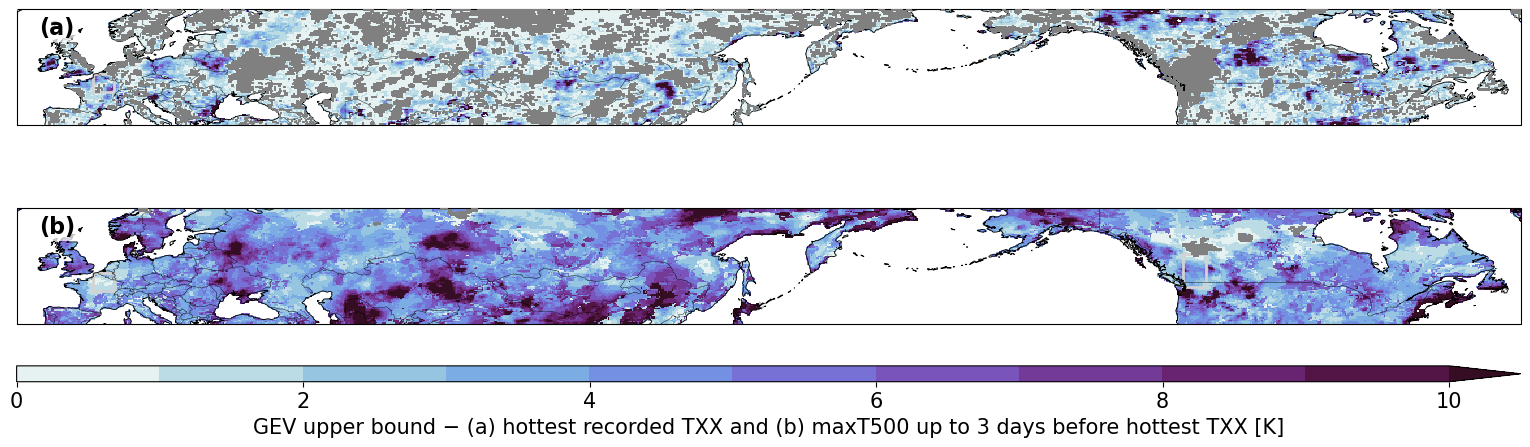

In [3]:
from matplotlib.colors import ListedColormap

# ============================================================
# Plot stacked maps
# ===========================================================

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

# Panel (a)
dist_t500_to_upper_raw = upper_endpoint_t500 - t500A
dist_t500_to_upper = dist_t500_to_upper_raw.where(dist_t500_to_upper_raw >= 0)

exceed_t500 = xr.where(
    (dist_t500_to_upper_raw < 0) & land_mask,
    1,
    np.nan
)

# Panel (b)
dist_txx_to_upper_raw = upper_endpoint_txx - txxB
dist_txx_to_upper = dist_txx_to_upper_raw.where(dist_txx_to_upper_raw >= 0)

exceed_txx = xr.where(
    (dist_txx_to_upper_raw < 0) & land_mask,
    1,
    np.nan
)

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

# ============================================================
# Layout with tight control
# ============================================================
fig = plt.figure(figsize=(16, 4.6))

gs = gridspec.GridSpec(
    nrows=3,
    ncols=1,
    height_ratios=[1, 1, 0.08],   # small colorbar row
    hspace=0.005                  # VERY tight vertical spacing
)

ax1 = fig.add_subplot(gs[0], projection=proj)
ax2 = fig.add_subplot(gs[1], projection=proj)
cax = fig.add_subplot(gs[2])

axes = [ax1, ax2]

levels = np.arange(0, 11, 1)
ticks = np.arange(0, 11, 1)

cmap = cmocean.cm.dense
grey_cmap = ListedColormap(["grey"])

plot_data = [
    (dist_txx_to_upper,  exceed_txx,  "(a)"),
    (dist_t500_to_upper, exceed_t500, "(b)"),
]

for ax, (da, exceed_da, panel_label) in zip(axes, plot_data):

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        extend="max",
    )

    # grey exceedances
    exceed_da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=grey_cmap,
        levels=[0.5, 1.5],
        add_colorbar=False,
        zorder=10,
    )

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    add_boxes(ax, data_crs)

    ax.text(
        0.015, 0.94, panel_label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

    ax.set_title("")

# ============================================================
# Colorbar EXACTLY matching axis width
# ============================================================
cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
)

cbar.set_label("GEV upper bound − (a) hottest recorded TXX and (b) maxT500 up to 3 days before hottest TXX [K]",     
               fontsize=15   # <-- label size
)

cbar.ax.tick_params(labelsize=15)
cbar.ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

# ============================================================
# Final tightening
# ============================================================
plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.98,
    bottom=0.08
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

Selected grid cell: lat=50.1639, lon=238.5000
shape in file = 0.157834
loc           = 265.163845
scale         = 1.371356
sample size   = 85


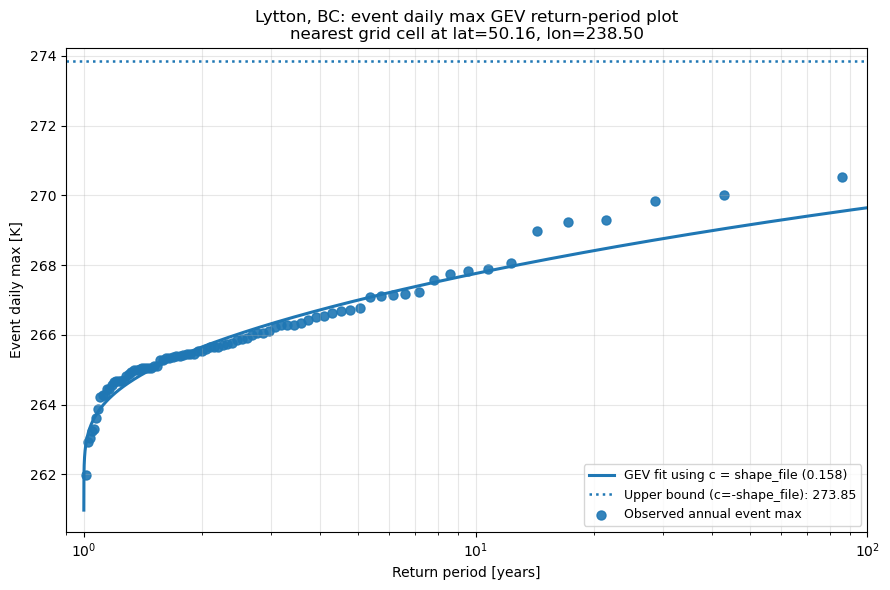

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# -----------------------
# Paths
# -----------------------
path_event  = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
path_params = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"

# -----------------------
# Lytton, British Columbia
# -----------------------
lat_city = 50.2306
lon_city = -121.5817

def convert_lon_to_dataset(lon, ds_lon):
    lon_min = float(ds_lon.min())
    if lon_min >= 0 and lon < 0:
        return lon % 360
    return lon

# -----------------------
# Load data
# -----------------------
ds_event = xr.open_dataset(path_event).sortby("lon")
ds_p     = xr.open_dataset(path_params).sortby("lon")

# pick event variable robustly
if "event" in ds_event.data_vars:
    event = ds_event["event"]
elif "event_max" in ds_event.data_vars:
    event = ds_event["event_max"]
elif "tdailymax" in ds_event.data_vars:
    event = ds_event["tdailymax"]
else:
    event = ds_event[list(ds_event.data_vars)[0]]

lon_city_use = convert_lon_to_dataset(lon_city, ds_event["lon"])

# nearest grid cell
event_pt = event.sel(lat=lat_city, lon=lon_city_use, method="nearest")

shape_file = ds_p["gev_shape_c"].sel(lat=lat_city, lon=lon_city_use, method="nearest")
loc_da     = ds_p["gev_loc"].sel(lat=lat_city, lon=lon_city_use, method="nearest")
scale_da   = ds_p["gev_scale"].sel(lat=lat_city, lon=lon_city_use, method="nearest")

lat_sel = float(event_pt["lat"])
lon_sel = float(event_pt["lon"])

time_dim = "year" if "year" in event_pt.dims else "time"

# observed values
event_vals = event_pt.dropna(dim=time_dim).values.astype(float)
event_vals = event_vals[np.isfinite(event_vals)]
event_sorted = np.sort(event_vals)
n = len(event_sorted)

# empirical return period for ascending annual/block maxima
ranks = np.arange(1, n + 1)
p_exceed_emp = (n + 1 - ranks) / (n + 1.0)
rp_emp = 1.0 / p_exceed_emp

shape_file = float(shape_file.values)
loc = float(loc_da.values)
scale = float(scale_da.values)

print(f"Selected grid cell: lat={lat_sel:.4f}, lon={lon_sel:.4f}")
print(f"shape in file = {shape_file:.6f}")
print(f"loc           = {loc:.6f}")
print(f"scale         = {scale:.6f}")
print(f"sample size   = {n}")

# -----------------------
# Build fitted curve
# -----------------------
def gev_return_curve(c, loc, scale, obs, npts=600):
    x_min = np.nanmin(obs) - 1.0

    if c < 0:
        upper = loc - scale / c
        x_max = upper - 1e-6
    else:
        upper = np.nan
        x_max = np.nanmax(obs) + 8.0

    x = np.linspace(x_min, x_max, npts)

    # survival function is numerically stable
    sf = genextreme.sf(x, c=c, loc=loc, scale=scale)
    mask = np.isfinite(sf) & (sf > 1e-10)

    x = x[mask]
    rp = 1.0 / sf[mask]
    return x, rp, upper

# use same convention as in your last diagnostic plot
x1, rp1, upper1 = gev_return_curve(shape_file, loc, scale, event_sorted)
x2, rp2, upper2 = gev_return_curve(-shape_file, loc, scale, event_sorted)

# -----------------------
# Plot (swapped axes)
# -----------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    rp_emp,
    event_sorted,
    s=42, alpha=0.9,
    label="Observed annual event max"
)

ax.plot(
    rp1,
    x1,
    linewidth=2.2,
    label=f"GEV fit using c = shape_file ({shape_file:.3f})"
)

# Optional second sign-convention curve
# ax.plot(
#     rp2,
#     x2,
#     linestyle="--",
#     linewidth=2.2,
#     label=f"GEV fit using c = -shape_file ({-shape_file:.3f})"
# )

if np.isfinite(upper1):
    ax.axhline(
        upper1,
        linestyle=":",
        linewidth=1.8,
        label=f"Upper bound (c=shape_file): {upper1:.2f}"
    )

if np.isfinite(upper2):
    ax.axhline(
        upper2,
        linestyle=":",
        linewidth=1.8,
        label=f"Upper bound (c=-shape_file): {upper2:.2f}"
    )

ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("Event daily max [K]")
ax.set_title(
    "Lytton, BC: event daily max GEV return-period plot\n"
    f"nearest grid cell at lat={lat_sel:.2f}, lon={lon_sel:.2f}"
)
ax.set_xlim(0.9,100)
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("Lytton_eventdailymax_return_period_plot.png", dpi=300, bbox_inches="tight")
plt.show()

268.3327177587686
Hottest TXx (Paris): 41.03 °C


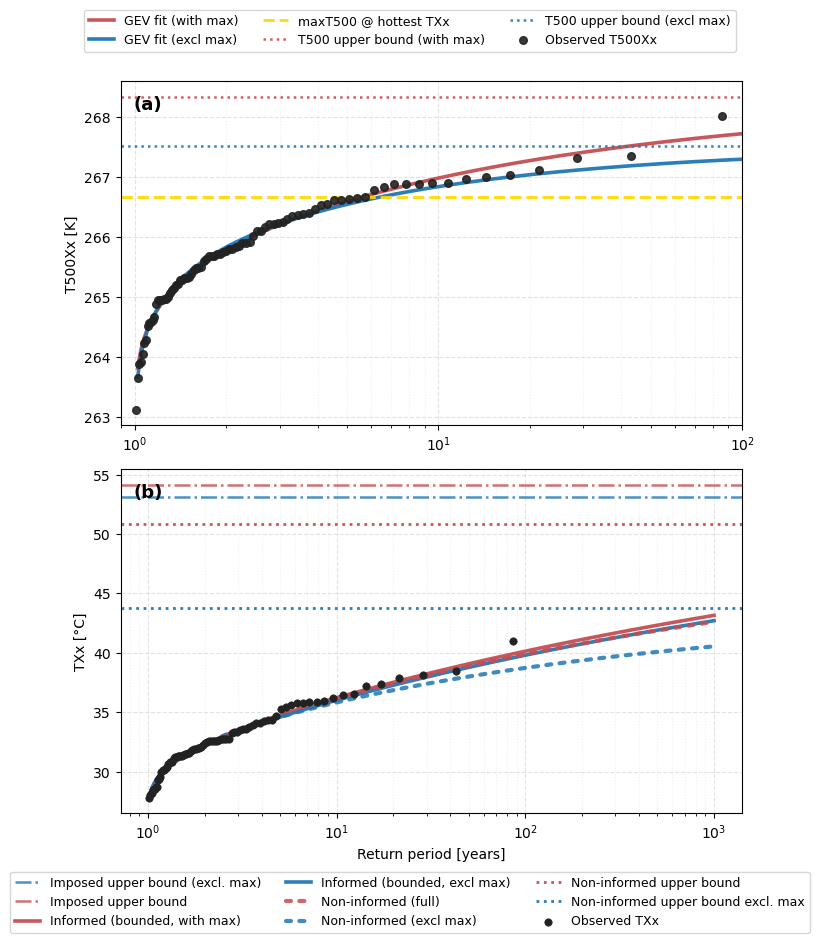

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# ======================================================
# Common settings
# ======================================================
lat_paris = 48.86
lon_paris = 2.35

col_with = "#C44E52"
col_excl = "#1F77B4"
col_obs  = "#222222"

def convert_lon_to_dataset(lon, ds_lon):
    lon_min = float(ds_lon.min())
    if lon_min >= 0 and lon < 0:
        return lon % 360
    return lon

# ======================================================
# Panel (a): T500Xx, Paris
# with and without max
# ======================================================
path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"

path_params_excl = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"
path_params_full = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024.nc"

ds_event = xr.open_dataset(path_event).sortby("lon")
ds_p_excl = xr.open_dataset(path_params_excl).sortby("lon")
ds_p_full = xr.open_dataset(path_params_full).sortby("lon")

if "event" in ds_event.data_vars:
    event = ds_event["event"]
elif "event_max" in ds_event.data_vars:
    event = ds_event["event_max"]
elif "tdailymax" in ds_event.data_vars:
    event = ds_event["tdailymax"]
else:
    event = ds_event[list(ds_event.data_vars)[0]]

event = event.rename("T500Xx")

lon_paris_use = convert_lon_to_dataset(lon_paris, ds_event["lon"])

event_pt = event.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")

fit_t500_excl = ds_p_excl.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")
fit_t500_full = ds_p_full.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")

c_t500_excl = float(fit_t500_excl["gev_shape_c"])
loc_t500_excl = float(fit_t500_excl["gev_loc"])
scale_t500_excl = float(fit_t500_excl["gev_scale"])

c_t500_full = float(fit_t500_full["gev_shape_c"])
loc_t500_full = float(fit_t500_full["gev_loc"])
scale_t500_full = float(fit_t500_full["gev_scale"])

lat_sel = float(event_pt["lat"])
lon_sel = float(event_pt["lon"])

time_dim = "year" if "year" in event_pt.dims else "time"

event_vals = event_pt.dropna(dim=time_dim).values.astype(float)
event_vals = event_vals[np.isfinite(event_vals)]

event_sorted = np.flip(np.sort(event_vals))
n_event = len(event_sorted)

rank_event = np.arange(1, n_event + 1)
T_emp_event = (n_event + 1) / rank_event

T_event = np.logspace(0, 3, 300)
p_event = 1 - 1 / T_event

gev_t500_excl = genextreme(
    c=c_t500_excl,
    loc=loc_t500_excl,
    scale=scale_t500_excl
)

gev_t500_full = genextreme(
    c=c_t500_full,
    loc=loc_t500_full,
    scale=scale_t500_full
)

x_T_t500_excl = gev_t500_excl.ppf(p_event)
x_T_t500_full = gev_t500_full.ppf(p_event)

upper_t500_excl = (
    loc_t500_excl + scale_t500_excl / c_t500_excl
    if c_t500_excl > 0 else np.nan
)

upper_t500_full = (
    loc_t500_full + scale_t500_full / c_t500_full
    if c_t500_full > 0 else np.nan
)


# ======================================================
# Panel (b): TXx return levels, Paris
# ======================================================
ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound.nc"
)

txx_paris = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris = ds_fit_boundeds.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris2 = ds_fit_boundeds2.sel(lat=lat_paris, lon=lon_paris, method="nearest")

c_b = float(fit_paris["gev_shape_c"])
loc_b = float(fit_paris["gev_loc"])
scale_b = float(fit_paris["gev_scale"])
U = float(fit_paris["upper_bound_used"])

c_b2 = float(fit_paris2["gev_shape_c"])
loc_b2 = float(fit_paris2["gev_loc"])
scale_b2 = float(fit_paris2["gev_scale"])
U2 = float(fit_paris2["upper_bound_used"])

data = txx_paris.values
data = data[np.isfinite(data)]

c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(data_excl)

T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(c=c_b, loc=loc_b, scale=scale_b)
gev_bounded2 = genextreme(c=c_b2, loc=loc_b2, scale=scale_b2)
gev_free_full = genextreme(c=c_free_full, loc=loc_free_full, scale=scale_free_full)
gev_free_excl = genextreme(c=c_free_excl, loc=loc_free_excl, scale=scale_free_excl)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

upper_free_full = (
    loc_free_full + scale_free_full / c_free_full
    if c_free_full > 0 else np.nan
)

upper_free_excl = (
    loc_free_excl + scale_free_excl / c_free_excl
    if c_free_excl > 0 else np.nan
)

# ------------------------------------------------------
# Paris t500_premax_3d at the hottest TXx event
# same event definition as stacked-map panel (a)
# ------------------------------------------------------

txx_pt = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
i_hot_paris = int(txx_pt.argmax(dim=time_dim, skipna=True))

t500_premax3d_pt = ds_band["t500_premax_3d"].sel(
    lat=lat_paris,
    lon=lon_paris,
    method="nearest"
)

t500_premax3d_hot = float(
    t500_premax3d_pt.isel({time_dim: i_hot_paris})
)

rank_premax3d = np.argmin(np.abs(event_sorted - t500_premax3d_hot)) + 1
T_premax3d = (n_event + 1) / rank_premax3d

# ======================================================
# Combined figure
# ======================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(7.2, 9.0),
    sharex=False
)

# -----------------------
# Panel (a)
# -----------------------
ax = axes[0]

ax.plot(
    T_event,
    x_T_t500_full,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="GEV fit (with max)"
)

ax.plot(
    T_event,
    x_T_t500_excl,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="GEV fit (excl max)"
)

ax.scatter(
    T_emp_event,
    event_sorted,
    s=30,
    color=col_obs,
    alpha=0.9,
    zorder=5,
    label="Observed T500Xx"
)

ax.axhline(
    t500_premax3d_hot,
    color="gold",
    linewidth=2.2,
    linestyle="--",
    alpha=0.9,
    label="maxT500 @ hottest TXx"
)

# Upper bounds stored in file, if available
if np.isfinite(upper_t500_full):
    ax.axhline(
        upper_t500_full,
        color=col_with,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (with max)"
    )
print(upper_t500_full)
if np.isfinite(upper_t500_excl):
    ax.axhline(
        upper_t500_excl,
        color=col_excl,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (excl max)"
    )

ax.set_xscale("log")
ax.set_xlim(0.9, 100)
ax.set_ylabel("T500Xx [K]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)

#ax.legend(
#    frameon=True,
#    framealpha=0.95,
#    fontsize=9,
#    loc="lower right"
#)

ax.text(
    0.02, 0.96, "(a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    fontweight="bold"
)
# -----------------------
# Panel (b)
# -----------------------
ax = axes[1]

ax.axhline(
    U - 273.15,
    color=col_excl,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound (excl. max)"
)

ax.axhline(
    U2 - 273.15,
    color=col_with,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound"
)

ax.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="Informed (bounded, with max)"
)

ax.plot(
    T, x_T_bounded - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="Informed (bounded, excl max)"
)

ax.plot(
    T, x_T_free_full - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_with,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (full)"
)

ax.plot(
    T, x_T_free_excl - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_excl,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (excl max)"
)
# Non-informed upper bounds
if np.isfinite(upper_free_full):
    ax.axhline(
        upper_free_full - 273.15,
        color=col_with,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound"
    )

if np.isfinite(upper_free_excl):
    ax.axhline(
        upper_free_excl - 273.15,
        color=col_excl,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound excl. max"
    )
    
ax.scatter(
    T_emp,
    data_sorted - 273.15,
    color=col_obs,
    linewidth=0.5,
    s=28,
    zorder=5,
    label="Observed TXx"
)

ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("TXx [°C]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)
#ax.legend(frameon=True, framealpha=0.95, fontsize=9)

ax.text(
    0.02, 0.96, "(b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    fontweight="bold"
)

# ======================================================
# Figure-level legends
# ======================================================

# --- Panel (a) legend (TOP) ---
handles_a, labels_a = axes[0].get_legend_handles_labels()

fig.legend(
    handles_a,
    labels_a,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    fontsize=9
)

# --- Panel (b) legend (BOTTOM) ---
handles_b, labels_b = axes[1].get_legend_handles_labels()

fig.legend(
    handles_b,
    labels_b,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True,
    fontsize=9
)
# ------------------------------------------------------
# Hottest TXx (same event) in Celsius
# ------------------------------------------------------

txx_hottest_K = float(txx_pt.isel({time_dim: i_hot_paris}))
txx_hottest_C = txx_hottest_K - 273.15

print(f"Hottest TXx (Paris): {txx_hottest_C:.2f} °C")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("Paris_combined_return_period_panels.png", dpi=300, bbox_inches="tight")
plt.show()

268.54010523608997
Hottest TXx (Paris): 40.74 °C


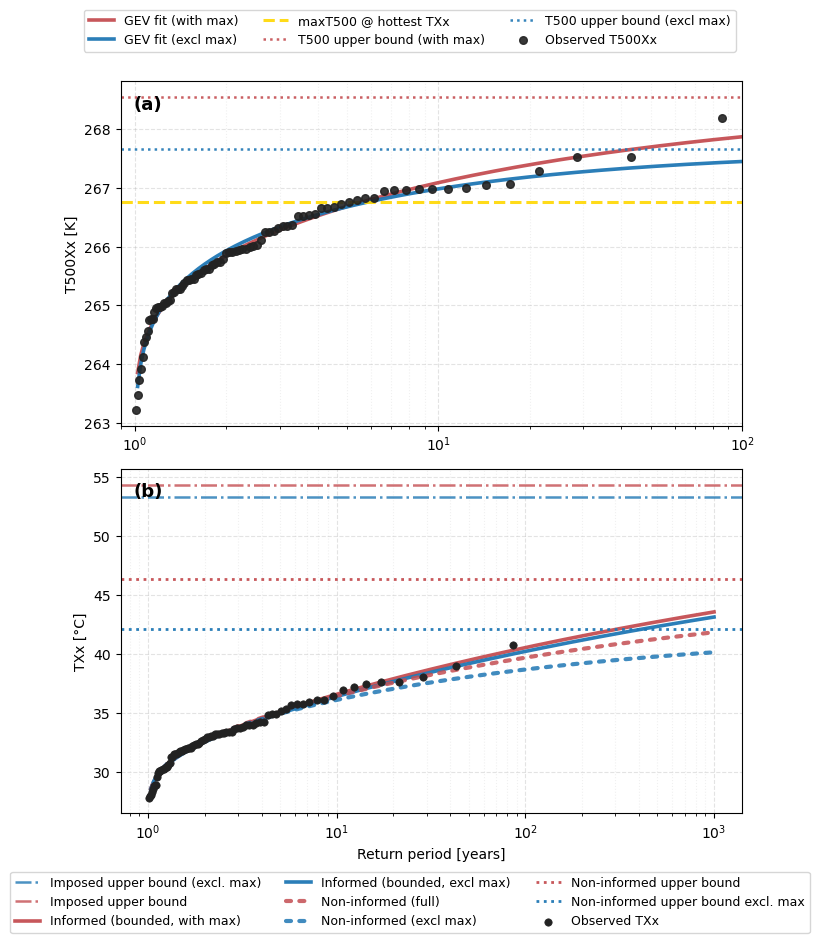

In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# ======================================================
# Common settings
# ======================================================
lat_paris = 48.86-0.5
lon_paris = 2.35

col_with = "#C44E52"
col_excl = "#1F77B4"
col_obs  = "#222222"

def convert_lon_to_dataset(lon, ds_lon):
    lon_min = float(ds_lon.min())
    if lon_min >= 0 and lon < 0:
        return lon % 360
    return lon

# ======================================================
# Panel (a): T500Xx, Paris
# with and without max
# ======================================================
path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"

path_params_excl = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"
path_params_full = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/gev_params_eventmax_1940_2024.nc"

ds_event = xr.open_dataset(path_event).sortby("lon")
ds_p_excl = xr.open_dataset(path_params_excl).sortby("lon")
ds_p_full = xr.open_dataset(path_params_full).sortby("lon")

if "event" in ds_event.data_vars:
    event = ds_event["event"]
elif "event_max" in ds_event.data_vars:
    event = ds_event["event_max"]
elif "tdailymax" in ds_event.data_vars:
    event = ds_event["tdailymax"]
else:
    event = ds_event[list(ds_event.data_vars)[0]]

event = event.rename("T500Xx")

lon_paris_use = convert_lon_to_dataset(lon_paris, ds_event["lon"])

event_pt = event.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")

fit_t500_excl = ds_p_excl.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")
fit_t500_full = ds_p_full.sel(lat=lat_paris, lon=lon_paris_use, method="nearest")

c_t500_excl = float(fit_t500_excl["gev_shape_c"])
loc_t500_excl = float(fit_t500_excl["gev_loc"])
scale_t500_excl = float(fit_t500_excl["gev_scale"])

c_t500_full = float(fit_t500_full["gev_shape_c"])
loc_t500_full = float(fit_t500_full["gev_loc"])
scale_t500_full = float(fit_t500_full["gev_scale"])

lat_sel = float(event_pt["lat"])
lon_sel = float(event_pt["lon"])

time_dim = "year" if "year" in event_pt.dims else "time"

event_vals = event_pt.dropna(dim=time_dim).values.astype(float)
event_vals = event_vals[np.isfinite(event_vals)]

event_sorted = np.flip(np.sort(event_vals))
n_event = len(event_sorted)

rank_event = np.arange(1, n_event + 1)
T_emp_event = (n_event + 1) / rank_event

T_event = np.logspace(0, 3, 300)
p_event = 1 - 1 / T_event

gev_t500_excl = genextreme(
    c=c_t500_excl,
    loc=loc_t500_excl,
    scale=scale_t500_excl
)

gev_t500_full = genextreme(
    c=c_t500_full,
    loc=loc_t500_full,
    scale=scale_t500_full
)

x_T_t500_excl = gev_t500_excl.ppf(p_event)
x_T_t500_full = gev_t500_full.ppf(p_event)

upper_t500_excl = (
    loc_t500_excl + scale_t500_excl / c_t500_excl
    if c_t500_excl > 0 else np.nan
)

upper_t500_full = (
    loc_t500_full + scale_t500_full / c_t500_full
    if c_t500_full > 0 else np.nan
)


# ======================================================
# Panel (b): TXx return levels, Paris
# ======================================================
ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/gev_params_TXX_with_t500hot_upperbound.nc"
)

txx_paris = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris = ds_fit_boundeds.sel(lat=lat_paris, lon=lon_paris, method="nearest")
fit_paris2 = ds_fit_boundeds2.sel(lat=lat_paris, lon=lon_paris, method="nearest")

c_b = float(fit_paris["gev_shape_c"])
loc_b = float(fit_paris["gev_loc"])
scale_b = float(fit_paris["gev_scale"])
U = float(fit_paris["upper_bound_used"])

c_b2 = float(fit_paris2["gev_shape_c"])
loc_b2 = float(fit_paris2["gev_loc"])
scale_b2 = float(fit_paris2["gev_scale"])
U2 = float(fit_paris2["upper_bound_used"])

data = txx_paris.values
data = data[np.isfinite(data)]

c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(data_excl)

T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(c=c_b, loc=loc_b, scale=scale_b)
gev_bounded2 = genextreme(c=c_b2, loc=loc_b2, scale=scale_b2)
gev_free_full = genextreme(c=c_free_full, loc=loc_free_full, scale=scale_free_full)
gev_free_excl = genextreme(c=c_free_excl, loc=loc_free_excl, scale=scale_free_excl)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

upper_free_full = (
    loc_free_full + scale_free_full / c_free_full
    if c_free_full > 0 else np.nan
)

upper_free_excl = (
    loc_free_excl + scale_free_excl / c_free_excl
    if c_free_excl > 0 else np.nan
)

# ------------------------------------------------------
# Paris t500_premax_3d at the hottest TXx event
# same event definition as stacked-map panel (a)
# ------------------------------------------------------

txx_pt = txx.sel(lat=lat_paris, lon=lon_paris, method="nearest")
i_hot_paris = int(txx_pt.argmax(dim=time_dim, skipna=True))

t500_premax3d_pt = ds_band["t500_premax_3d"].sel(
    lat=lat_paris,
    lon=lon_paris,
    method="nearest"
)

t500_premax3d_hot = float(
    t500_premax3d_pt.isel({time_dim: i_hot_paris})
)

rank_premax3d = np.argmin(np.abs(event_sorted - t500_premax3d_hot)) + 1
T_premax3d = (n_event + 1) / rank_premax3d

# ======================================================
# Combined figure
# ======================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(7.2, 9.0),
    sharex=False
)

# -----------------------
# Panel (a)
# -----------------------
ax = axes[0]

ax.plot(
    T_event,
    x_T_t500_full,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="GEV fit (with max)"
)

ax.plot(
    T_event,
    x_T_t500_excl,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="GEV fit (excl max)"
)

ax.scatter(
    T_emp_event,
    event_sorted,
    s=30,
    color=col_obs,
    alpha=0.9,
    zorder=5,
    label="Observed T500Xx"
)

ax.axhline(
    t500_premax3d_hot,
    color="gold",
    linewidth=2.2,
    linestyle="--",
    alpha=0.9,
    label="maxT500 @ hottest TXx"
)

# Upper bounds stored in file, if available
if np.isfinite(upper_t500_full):
    ax.axhline(
        upper_t500_full,
        color=col_with,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (with max)"
    )
print(upper_t500_full)
if np.isfinite(upper_t500_excl):
    ax.axhline(
        upper_t500_excl,
        color=col_excl,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (excl max)"
    )

ax.set_xscale("log")
ax.set_xlim(0.9, 100)
ax.set_ylabel("T500Xx [K]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)

#ax.legend(
#    frameon=True,
#    framealpha=0.95,
#    fontsize=9,
#    loc="lower right"
#)

ax.text(
    0.02, 0.96, "(a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    fontweight="bold"
)
# -----------------------
# Panel (b)
# -----------------------
ax = axes[1]

ax.axhline(
    U - 273.15,
    color=col_excl,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound (excl. max)"
)

ax.axhline(
    U2 - 273.15,
    color=col_with,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound"
)

ax.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="Informed (bounded, with max)"
)

ax.plot(
    T, x_T_bounded - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="Informed (bounded, excl max)"
)

ax.plot(
    T, x_T_free_full - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_with,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (full)"
)

ax.plot(
    T, x_T_free_excl - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_excl,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (excl max)"
)
# Non-informed upper bounds
if np.isfinite(upper_free_full):
    ax.axhline(
        upper_free_full - 273.15,
        color=col_with,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound"
    )

if np.isfinite(upper_free_excl):
    ax.axhline(
        upper_free_excl - 273.15,
        color=col_excl,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound excl. max"
    )
    
ax.scatter(
    T_emp,
    data_sorted - 273.15,
    color=col_obs,
    linewidth=0.5,
    s=28,
    zorder=5,
    label="Observed TXx"
)

ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("TXx [°C]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)
#ax.legend(frameon=True, framealpha=0.95, fontsize=9)

ax.text(
    0.02, 0.96, "(b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=13,
    fontweight="bold"
)

# ======================================================
# Figure-level legends
# ======================================================

# --- Panel (a) legend (TOP) ---
handles_a, labels_a = axes[0].get_legend_handles_labels()

fig.legend(
    handles_a,
    labels_a,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    fontsize=9
)

# --- Panel (b) legend (BOTTOM) ---
handles_b, labels_b = axes[1].get_legend_handles_labels()

fig.legend(
    handles_b,
    labels_b,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True,
    fontsize=9
)
# ------------------------------------------------------
# Hottest TXx (same event) in Celsius
# ------------------------------------------------------

txx_hottest_K = float(txx_pt.isel({time_dim: i_hot_paris}))
txx_hottest_C = txx_hottest_K - 273.15

print(f"Hottest TXx (Paris): {txx_hottest_C:.2f} °C")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("Paris_combined_return_period_panels.png", dpi=300, bbox_inches="tight")
plt.show()

T500Xx grid cell: lat=51.57, lon=239.91
TXx grid cell: lat=51.57, lon=239.91
277.16306201029187
Hottest TXx (Lytton): 39.95 °C
Finite bounded excl: 199
Range bounded excl: -inf 311.82442418837286
Parameters: 0.09936540694479098 301.6493805488905 2.035996848698144


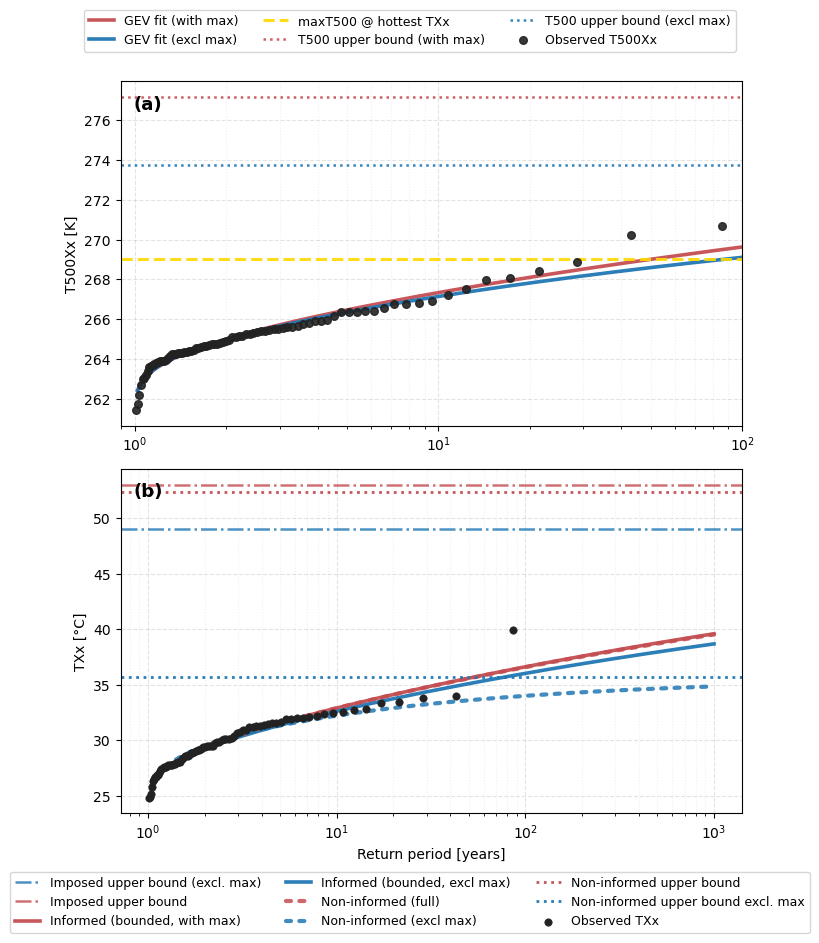

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# ======================================================
# Common settings
# ======================================================
# Lytton, British Columbia
lat_lytton = 51.5
lon_lytton = 240.0  # equivalent to 120°W

col_with = "#C44E52"
col_excl = "#1F77B4"
col_obs = "#222222"


def convert_lon_to_dataset(lon, ds_lon):
    lon_min = float(ds_lon.min())

    if lon_min >= 0 and lon < 0:
        return lon % 360

    return lon


def select_lytton(obj):
    lon_use = convert_lon_to_dataset(lon_lytton, obj["lon"])

    return obj.sel(
        lat=lat_lytton,
        lon=lon_use,
        method="nearest"
    )


# ======================================================
# Panel (a): T500Xx, Lytton
# with and without max
# ======================================================
path_event = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/"
    "TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
)

path_params_excl = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/"
    "TDAILYMAX/gev_params_eventmax_1940_2024_exclmax.nc"
)

path_params_full = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/"
    "TDAILYMAX/gev_params_eventmax_1940_2024.nc"
)

ds_event = xr.open_dataset(path_event).sortby("lon")
ds_p_excl = xr.open_dataset(path_params_excl).sortby("lon")
ds_p_full = xr.open_dataset(path_params_full).sortby("lon")

if "event" in ds_event.data_vars:
    event = ds_event["event"]
elif "event_max" in ds_event.data_vars:
    event = ds_event["event_max"]
elif "tdailymax" in ds_event.data_vars:
    event = ds_event["tdailymax"]
else:
    event = ds_event[list(ds_event.data_vars)[0]]

event = event.rename("T500Xx")

event_pt = select_lytton(event)
fit_t500_excl = select_lytton(ds_p_excl)
fit_t500_full = select_lytton(ds_p_full)

c_t500_excl = float(fit_t500_excl["gev_shape_c"])
loc_t500_excl = float(fit_t500_excl["gev_loc"])
scale_t500_excl = float(fit_t500_excl["gev_scale"])

c_t500_full = float(fit_t500_full["gev_shape_c"])
loc_t500_full = float(fit_t500_full["gev_loc"])
scale_t500_full = float(fit_t500_full["gev_scale"])

lat_sel = float(event_pt["lat"])
lon_sel = float(event_pt["lon"])

print(
    f"T500Xx grid cell: lat={lat_sel:.2f}, "
    f"lon={lon_sel:.2f}"
)

time_dim = "year" if "year" in event_pt.dims else "time"

event_vals = event_pt.dropna(dim=time_dim).values.astype(float)
event_vals = event_vals[np.isfinite(event_vals)]

event_sorted = np.flip(np.sort(event_vals))
n_event = len(event_sorted)

rank_event = np.arange(1, n_event + 1)
T_emp_event = (n_event + 1) / rank_event

T_event = np.logspace(0, 3, 300)
p_event = 1 - 1 / T_event

gev_t500_excl = genextreme(
    c=c_t500_excl,
    loc=loc_t500_excl,
    scale=scale_t500_excl
)

gev_t500_full = genextreme(
    c=c_t500_full,
    loc=loc_t500_full,
    scale=scale_t500_full
)

x_T_t500_excl = gev_t500_excl.ppf(p_event)
x_T_t500_full = gev_t500_full.ppf(p_event)

upper_t500_excl = (
    loc_t500_excl + scale_t500_excl / c_t500_excl
    if c_t500_excl > 0 else np.nan
)

upper_t500_full = (
    loc_t500_full + scale_t500_full / c_t500_full
    if c_t500_full > 0 else np.nan
)


# ======================================================
# Panel (b): TXx return levels, Lytton
# ======================================================
ds_fit_boundeds = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound_exclmax_exclmax.nc"
)

ds_fit_boundeds2 = xr.open_dataset(
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "gev_params_TXX_with_t500hot_upperbound.nc"
)

txx_lytton = select_lytton(txx)
fit_lytton = select_lytton(ds_fit_boundeds)
fit_lytton2 = select_lytton(ds_fit_boundeds2)

print(
    f"TXx grid cell: lat={float(txx_lytton['lat']):.2f}, "
    f"lon={float(txx_lytton['lon']):.2f}"
)

c_b = float(fit_lytton["gev_shape_c"])
loc_b = float(fit_lytton["gev_loc"])
scale_b = float(fit_lytton["gev_scale"])
U = float(fit_lytton["upper_bound_used"])

c_b2 = float(fit_lytton2["gev_shape_c"])
loc_b2 = float(fit_lytton2["gev_loc"])
scale_b2 = float(fit_lytton2["gev_scale"])
U2 = float(fit_lytton2["upper_bound_used"])

data = txx_lytton.values
data = data[np.isfinite(data)]

# Non-informed fit using all values
c_free_full, loc_free_full, scale_free_full = genextreme.fit(data)

# Non-informed fit excluding the maximum
data_excl = data.copy()
max_val = np.nanmax(data_excl)
data_excl = data_excl[data_excl < max_val]

c_free_excl, loc_free_excl, scale_free_excl = genextreme.fit(
    data_excl
)

T = np.logspace(0, 3, 200)
p = 1 - 1 / T

gev_bounded = genextreme(
    c=c_b,
    loc=loc_b,
    scale=scale_b
)

gev_bounded2 = genextreme(
    c=c_b2,
    loc=loc_b2,
    scale=scale_b2
)

gev_free_full = genextreme(
    c=c_free_full,
    loc=loc_free_full,
    scale=scale_free_full
)

gev_free_excl = genextreme(
    c=c_free_excl,
    loc=loc_free_excl,
    scale=scale_free_excl
)

x_T_bounded = gev_bounded.ppf(p)
x_T_bounded2 = gev_bounded2.ppf(p)
x_T_free_full = gev_free_full.ppf(p)
x_T_free_excl = gev_free_excl.ppf(p)

data_sorted = np.flip(np.sort(data))
n = len(data_sorted)

rank = np.arange(1, n + 1)
T_emp = (n + 1) / rank

upper_free_full = (
    loc_free_full + scale_free_full / c_free_full
    if c_free_full > 0 else np.nan
)

upper_free_excl = (
    loc_free_excl + scale_free_excl / c_free_excl
    if c_free_excl > 0 else np.nan
)


# ------------------------------------------------------
# Lytton t500_premax_3d at the hottest TXx event
# same event definition as stacked-map panel (a)
# ------------------------------------------------------
txx_pt = select_lytton(txx)

time_dim_txx = (
    "year" if "year" in txx_pt.dims else "time"
)

i_hot_lytton = int(
    txx_pt.argmax(dim=time_dim_txx, skipna=True)
)

t500_premax3d_pt2 = select_lytton(
    ds_band["t500_premax_3d"]
)

t500_time_dim = (
    "year"
    if "year" in t500_premax3d_pt2.dims
    else "time"
)

t500_premax3d_hot = float(
    t500_premax3d_pt2.isel(
        {t500_time_dim: i_hot_lytton}
    )
)

rank_premax3d = (
    np.argmin(
        np.abs(event_sorted - t500_premax3d_hot)
    ) + 1
)

T_premax3d = (n_event + 1) / rank_premax3d


# ======================================================
# Combined figure
# ======================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(7.2, 9.0),
    sharex=False
)


# -----------------------
# Panel (a)
# -----------------------
ax = axes[0]

ax.plot(
    T_event,
    x_T_t500_full,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="GEV fit (with max)"
)

ax.plot(
    T_event,
    x_T_t500_excl,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="GEV fit (excl max)"
)

ax.scatter(
    T_emp_event,
    event_sorted,
    s=30,
    color=col_obs,
    alpha=0.9,
    zorder=5,
    label="Observed T500Xx"
)

ax.axhline(
    t500_premax3d_hot,
    color="gold",
    linewidth=2.2,
    linestyle="--",
    alpha=0.9,
    label="maxT500 @ hottest TXx"
)

if np.isfinite(upper_t500_full):
    ax.axhline(
        upper_t500_full,
        color=col_with,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (with max)"
    )

print(upper_t500_full)

if np.isfinite(upper_t500_excl):
    ax.axhline(
        upper_t500_excl,
        color=col_excl,
        linewidth=1.8,
        linestyle=":",
        alpha=0.9,
        label="T500 upper bound (excl max)"
    )

ax.set_xscale("log")
ax.set_xlim(0.9, 100)
ax.set_ylabel("T500Xx [K]")

ax.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    True,
    which="minor",
    linestyle=":",
    alpha=0.18
)

ax.text(
    0.02, 0.96, "(a)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# -----------------------
# Panel (b)
# -----------------------
ax = axes[1]

ax.axhline(
    U - 273.15,
    color=col_excl,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound (excl. max)"
)

ax.axhline(
    U2 - 273.15,
    color=col_with,
    linewidth=1.8,
    linestyle="-.",
    alpha=0.8,
    label="Imposed upper bound"
)

ax.plot(
    T,
    x_T_bounded2 - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_with,
    label="Informed (bounded, with max)"
)

ax.plot(
    T,
    x_T_bounded - 273.15,
    linewidth=2.6,
    alpha=0.95,
    color=col_excl,
    label="Informed (bounded, excl max)"
)

ax.plot(
    T,
    x_T_free_full - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_with,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (full)"
)

ax.plot(
    T,
    x_T_free_excl - 273.15,
    linewidth=3.0,
    alpha=0.85,
    color=col_excl,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (excl max)"
)

if np.isfinite(upper_free_full):
    ax.axhline(
        upper_free_full - 273.15,
        color=col_with,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound"
    )

if np.isfinite(upper_free_excl):
    ax.axhline(
        upper_free_excl - 273.15,
        color=col_excl,
        linewidth=2.0,
        linestyle=":",
        alpha=0.95,
        label="Non-informed upper bound excl. max"
    )

ax.scatter(
    T_emp,
    data_sorted - 273.15,
    color=col_obs,
    linewidth=0.5,
    s=28,
    zorder=5,
    label="Observed TXx"
)

ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("TXx [°C]")

ax.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.35
)

ax.grid(
    True,
    which="minor",
    linestyle=":",
    alpha=0.18
)

ax.text(
    0.02, 0.96, "(b)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# ======================================================
# Figure-level legends
# ======================================================
handles_a, labels_a = axes[0].get_legend_handles_labels()

fig.legend(
    handles_a,
    labels_a,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    fontsize=9
)

handles_b, labels_b = axes[1].get_legend_handles_labels()

fig.legend(
    handles_b,
    labels_b,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True,
    fontsize=9
)


# ------------------------------------------------------
# Hottest TXx in Celsius
# ------------------------------------------------------
txx_hottest_K = float(
    txx_pt.isel({time_dim_txx: i_hot_lytton})
)

txx_hottest_C = txx_hottest_K - 273.15

print(
    f"Hottest TXx (Lytton): "
    f"{txx_hottest_C:.2f} °C"
)
print("Finite bounded excl:", np.isfinite(x_T_bounded).sum())
print("Range bounded excl:", np.nanmin(x_T_bounded), np.nanmax(x_T_bounded))
print("Parameters:", c_b, loc_b, scale_b)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig(
    "Lytton_combined_return_period_panels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
vals = event_pt.values.astype(float)
valid_idx = np.where(np.isfinite(vals))[0]

sorted_idx = valid_idx[np.argsort(vals[valid_idx])[::-1]]

i_second = int(sorted_idx[1])
# Get date
print(
    ds_event["event_yyyymmdd"]
    .sel(lat=lat_paris, lon=lon_paris_use, method="nearest")
    .isel({time_dim: i_second})
    .values
)

20220724


In [ ]:
# ======================================================
# Plot block (slim + large fonts)
# ======================================================
import matplotlib.pyplot as plt

# Global font scaling
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13
})

# ======================================================
# Combined figure (slimmer)
# ======================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(6, 10),
    sharex=False
)

# -----------------------
# Panel (a)
# -----------------------
ax = axes[0]

ax.plot(
    T_event,
    x_T_t500_full,
    linewidth=3.2,
    alpha=0.95,
    color=col_with,
    label="GEV fit (with max)"
)

ax.plot(
    T_event,
    x_T_t500_excl,
    linewidth=3.2,
    alpha=0.95,
    color=col_excl,
    label="GEV fit (excl max)"
)

ax.scatter(
    T_emp_event,
    event_sorted,
    s=45,
    color=col_obs,
    alpha=0.9,
    zorder=5,
    label="Observed T500Xx"
)

if np.isfinite(upper_t500_full):
    ax.axhline(
        upper_t500_full,
        color=col_with,
        linewidth=2.2,
        linestyle="-.",
        alpha=0.9,
        label="T500 upper bound (with max)"
    )

if np.isfinite(upper_t500_excl):
    ax.axhline(
        upper_t500_excl,
        color=col_excl,
        linewidth=2.2,
        linestyle="-.",
        alpha=0.9,
        label="T500 upper bound (excl max)"
    )

ax.set_xscale("log")
ax.set_xlim(0.9, 100)
ax.set_ylabel("(a) T500Xx [K]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)

# -----------------------
# Panel (b)
# -----------------------
ax = axes[1]

ax.axhline(
    U - 273.15,
    color=col_excl,
    linewidth=2.2,
    linestyle="-.",
    alpha=0.8,
    label="Imposed bound (excl. max)"
)

ax.axhline(
    U2 - 273.15,
    color=col_with,
    linewidth=2.2,
    linestyle="-.",
    alpha=0.8,
    label="Imposed bound"
)

ax.plot(
    T, x_T_bounded2 - 273.15,
    linewidth=3.2,
    alpha=0.95,
    color=col_with,
    label="Informed (bounded, with max)"
)

ax.plot(
    T, x_T_bounded - 273.15,
    linewidth=3.2,
    alpha=0.95,
    color=col_excl,
    label="Informed (bounded, excl max)"
)

ax.plot(
    T, x_T_free_full - 273.15,
    linewidth=3.4,
    alpha=0.85,
    color=col_with,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (full)"
)

ax.plot(
    T, x_T_free_excl - 273.15,
    linewidth=3.4,
    alpha=0.85,
    color=col_excl,
    linestyle=(0, (1.2, 2.0)),
    dash_capstyle="round",
    label="Non-informed (excl max)"
)

if np.isfinite(upper_free_full):
    ax.axhline(
        upper_free_full - 273.15,
        color=col_with,
        linewidth=2.2,
        linestyle=":",
        alpha=0.95,
        label="Non-informed bound"
    )

if np.isfinite(upper_free_excl):
    ax.axhline(
        upper_free_excl - 273.15,
        color=col_excl,
        linewidth=2.2,
        linestyle=":",
        alpha=0.95,
        label="Non-informed bound excl. max"
    )

ax.scatter(
    T_emp,
    data_sorted - 273.15,
    color=col_obs,
    s=40,
    zorder=5,
    label="Observed TXx"
)

ax.set_xscale("log")
ax.set_xlabel("Return period [years]")
ax.set_ylabel("(b) TXx [°C]")

ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.grid(True, which="minor", linestyle=":", alpha=0.18)


# ======================================================
# Figure-level legends (fixed width)
# ======================================================

# -----------------------
# Panel (a) legend
# -----------------------
axes[0].legend(
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    fontsize=9
)

# -----------------------
# Panel (b) legend
# -----------------------
axes[1].legend(
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=9
)

# ======================================================
# Tight layout
# ======================================================
plt.tight_layout(rect=[0, 0.04, 1, 0.96])

plt.savefig("Paris_combined_return_period_panels.png", dpi=300, bbox_inches="tight")
plt.show()

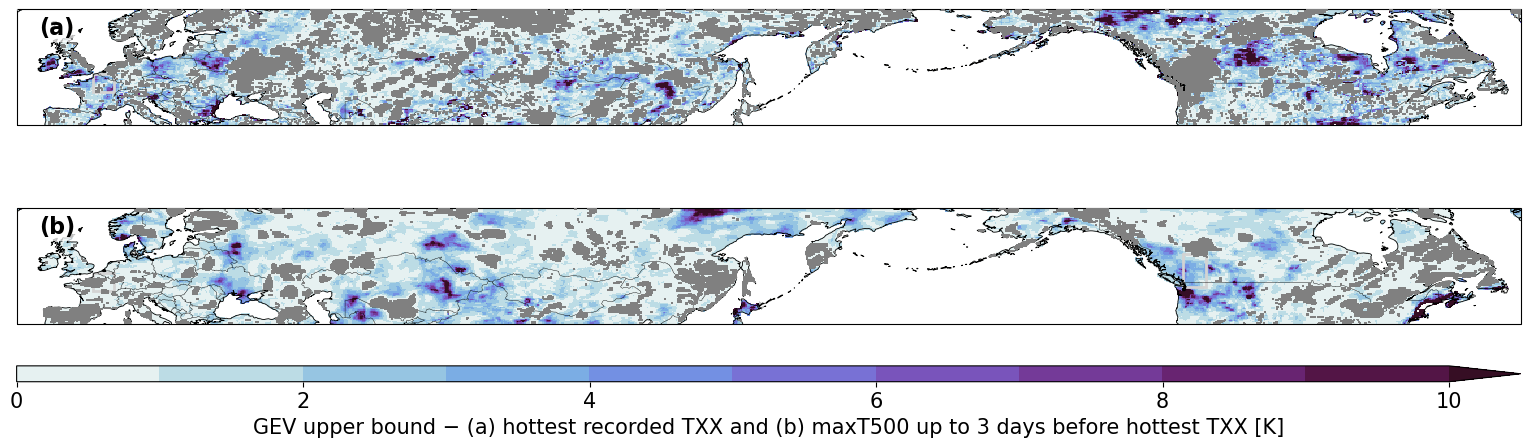

In [17]:
from matplotlib.colors import ListedColormap

# ============================================================
# Plot stacked maps
# ===========================================================

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

# Panel (a)
dist_t500_to_upper_raw = upper_endpoint_t500 - t500A
dist_t500_to_upper = dist_t500_to_upper_raw.where(dist_t500_to_upper_raw >= 0)

exceed_t500 = xr.where(
    (dist_t500_to_upper_raw < 0) & land_mask,
    1,
    np.nan
)

# ============================================================
# Panel (b): T500XX (from event file) to GEV upper endpoint
# ============================================================

# Load event dataset
path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
ds_event = xr.open_dataset(path_event).sortby("lon")

# apply same lat band
ds_event = sel_lat_band(ds_event, lat_min, lat_max).sortby("lon")

# pick T500 variable from event file (adjust if needed)
if "event_max" in ds_event.data_vars:
    t500 = ds_event["event_max"]
elif "T500" in ds_event.data_vars:
    t500 = ds_event["T500"]
else:
    raise ValueError(f"No T500 variable found in {list(ds_event.data_vars)}")

# apply land mask
t500_land = t500.where(land_mask)

# get maximum T500 (T500XX)
t500xx = t500_land.max(dim=time_dim, skipna=True)

# align with GEV parameters (T500 GEV!)
cA, locA, scaleA, t500A = xr.align(
    c_t500, loc_t500, scale_t500, t500xx,
    join="inner"
)

# compute endpoint + distance
upper_endpoint_t500 = xr.where(
    cA < 0,
    locA - scaleA / cA,
    np.nan
)

dist_t500_to_upper_raw = upper_endpoint_t500 - t500A
dist_t500_to_upper = dist_t500_to_upper_raw.where(dist_t500_to_upper_raw >= 0)

# exceedances
exceed_t500 = xr.where(
    (dist_t500_to_upper_raw < 0) & land_mask,
    1,
    np.nan
)
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

# ============================================================
# Layout with tight control
# ============================================================
fig = plt.figure(figsize=(16, 4.6))

proj = ccrs.PlateCarree(central_longitude=135)

gs = gridspec.GridSpec(
    nrows=3,
    ncols=1,
    height_ratios=[1, 1, 0.08],   # small colorbar row
    hspace=0.005                  # VERY tight vertical spacing
)

ax1 = fig.add_subplot(gs[0], projection=proj)
ax2 = fig.add_subplot(gs[1], projection=proj)
cax = fig.add_subplot(gs[2])

axes = [ax1, ax2]

levels = np.arange(0, 11, 1)
ticks = np.arange(0, 11, 1)

cmap = cmocean.cm.dense
grey_cmap = ListedColormap(["grey"])

plot_data = [
    (dist_txx_to_upper,  exceed_txx,  "(a)"),
    (dist_t500_to_upper, exceed_t500, "(b)"),
]

for ax, (da, exceed_da, panel_label) in zip(axes, plot_data):

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        extend="max",
    )

    # grey exceedances
    exceed_da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=grey_cmap,
        levels=[0.5, 1.5],
        add_colorbar=False,
        zorder=10,
    )

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    add_boxes(ax, data_crs)

    ax.text(
        0.015, 0.94, panel_label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

    ax.set_title("")

# ============================================================
# Colorbar EXACTLY matching axis width
# ============================================================
cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
)

cbar.set_label("GEV upper bound − (a) hottest recorded TXX and (b) maxT500 up to 3 days before hottest TXX [K]",     
               fontsize=15   # <-- label size
)

cbar.ax.tick_params(labelsize=15)
cbar.ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

# ============================================================
# Final tightening
# ============================================================
plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.98,
    bottom=0.08
)

#plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

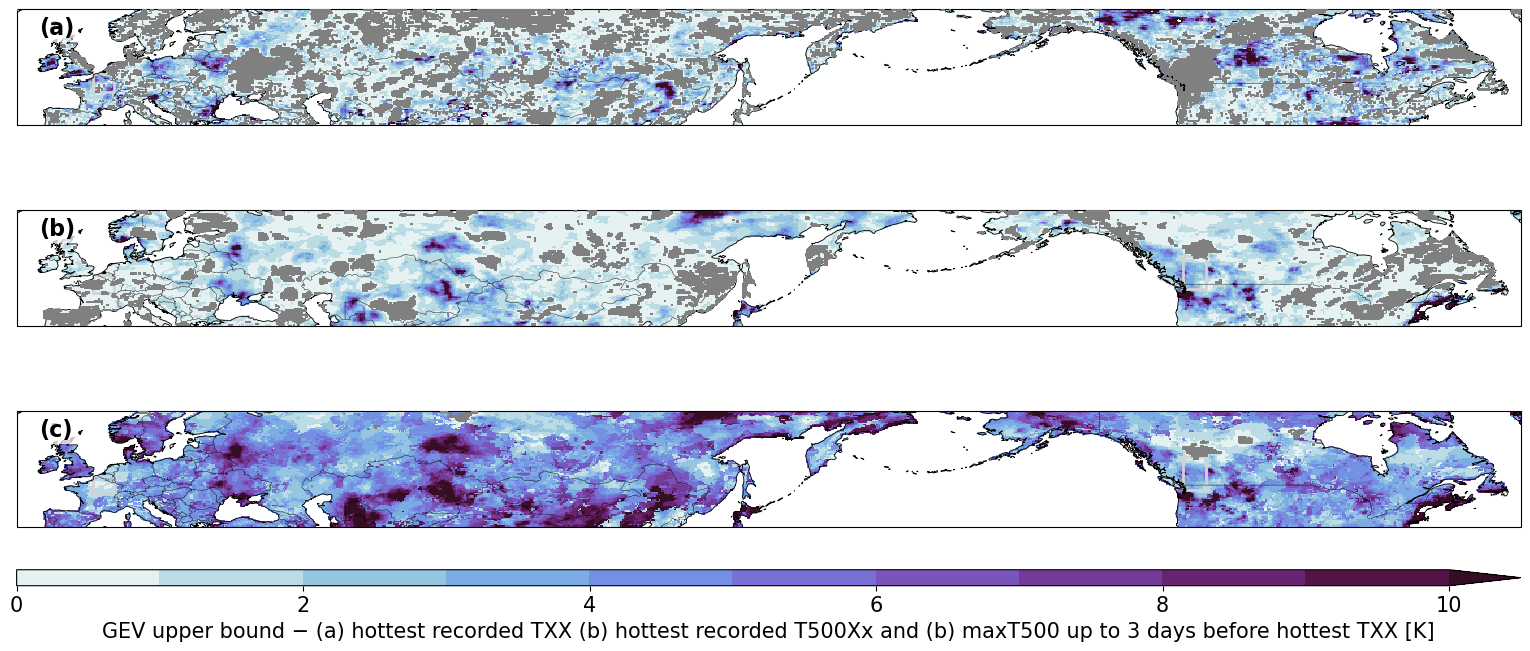

In [25]:
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

# ============================================================
# Panel (a): hottest recorded TXX
# ============================================================
dist_a_raw = upper_endpoint_txx - txxB
dist_a = dist_a_raw.where(dist_a_raw >= 0)

exceed_a = xr.where(
    (dist_a_raw < 0) & land_mask,
    1,
    np.nan
)

# ============================================================
# Panel (b): your existing T500XX panel
# KEEP whatever you computed before for T500XX
# ============================================================
dist_b_raw = dist_t500xx_to_upper_raw
dist_b = dist_t500xx_to_upper
exceed_b = exceed_t500xx

# ============================================================
# Panel (c): EXACT old plot-b
# maxT500 up to 3 days before hottest TXX
# source: ds_band["t500_premax_3d"]
# ============================================================

i_hot_c = txx.argmax(time_dim, skipna=True)

t500_hot_c = ds_band["t500_premax_3d"].isel({time_dim: i_hot_c})
t500_hot_c_land = t500_hot_c.where(land_mask)

c_c, loc_c, scale_c, t500_c = xr.align(
    c_t500, loc_t500, scale_t500, t500_hot_c_land,
    join="inner"
)

upper_c = xr.where(
    c_c < 0,
    loc_c - scale_c / c_c,
    np.nan
)

dist_c_raw = upper_c - t500_c
dist_c = dist_c_raw.where(dist_c_raw >= 0)

exceed_c = xr.where(
    (dist_c_raw < 0) & land_mask,
    1,
    np.nan
)

# ============================================================
# Plot stacked maps
# ============================================================
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 6.8))

gs = gridspec.GridSpec(
    nrows=4,
    ncols=1,
    height_ratios=[1, 1, 1, 0.08],
    hspace=0.005
)

ax1 = fig.add_subplot(gs[0], projection=proj)
ax2 = fig.add_subplot(gs[1], projection=proj)
ax3 = fig.add_subplot(gs[2], projection=proj)
cax = fig.add_subplot(gs[3])

axes = [ax1, ax2, ax3]

levels = np.arange(0, 11, 1)
ticks = np.arange(0, 11, 1)

cmap = cmocean.cm.dense
grey_cmap = ListedColormap(["grey"])

plot_data = [
    (dist_a, exceed_a, "(a)"),
    (dist_b, exceed_b, "(b)"),
    (dist_c, exceed_c, "(c)"),
]

for ax, (da, exceed_da, panel_label) in zip(axes, plot_data):

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        extend="max",
    )

    exceed_da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=grey_cmap,
        levels=[0.5, 1.5],
        add_colorbar=False,
        zorder=10,
    )

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    add_boxes(ax, data_crs)

    ax.text(
        0.015, 0.94, panel_label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

    ax.set_title("")

# ============================================================
# Colorbar
# ============================================================
cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
)

cbar.set_label(
    "GEV upper bound − (a) hottest recorded TXX (b) hottest recorded T500Xx and (b) maxT500 up to 3 days before hottest TXX [K]",
    fontsize=15
)

cbar.ax.tick_params(labelsize=15)
cbar.ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.98,
    bottom=0.07
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()